# Regression and Evaluation
---

In [5]:
import pandas as pd
import numpy as np

In [7]:
from sklearn.datasets import fetch_california_housing

In [8]:
# load dataset
data = fetch_california_housing()

In [22]:
#converting dataset in to dataframe

df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target

In [10]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [11]:
df.shape

(20640, 9)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [13]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [14]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64

### There is no missing values in this Dataset.

## Feature Scaling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [18]:
x = df.drop('Target', axis=1)
y = df['Target']

In [20]:
#train-test split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [29]:
# standardization
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

I choose Standardization because it handles the outliers in features like Population and AveRooms much more effectively than normalization. This ensures that distance-based models like the Support Vector Regressor are not biased by different feature scales, leading to faster and more accurate convergence.

## Exploratory data analysis (EDA)


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

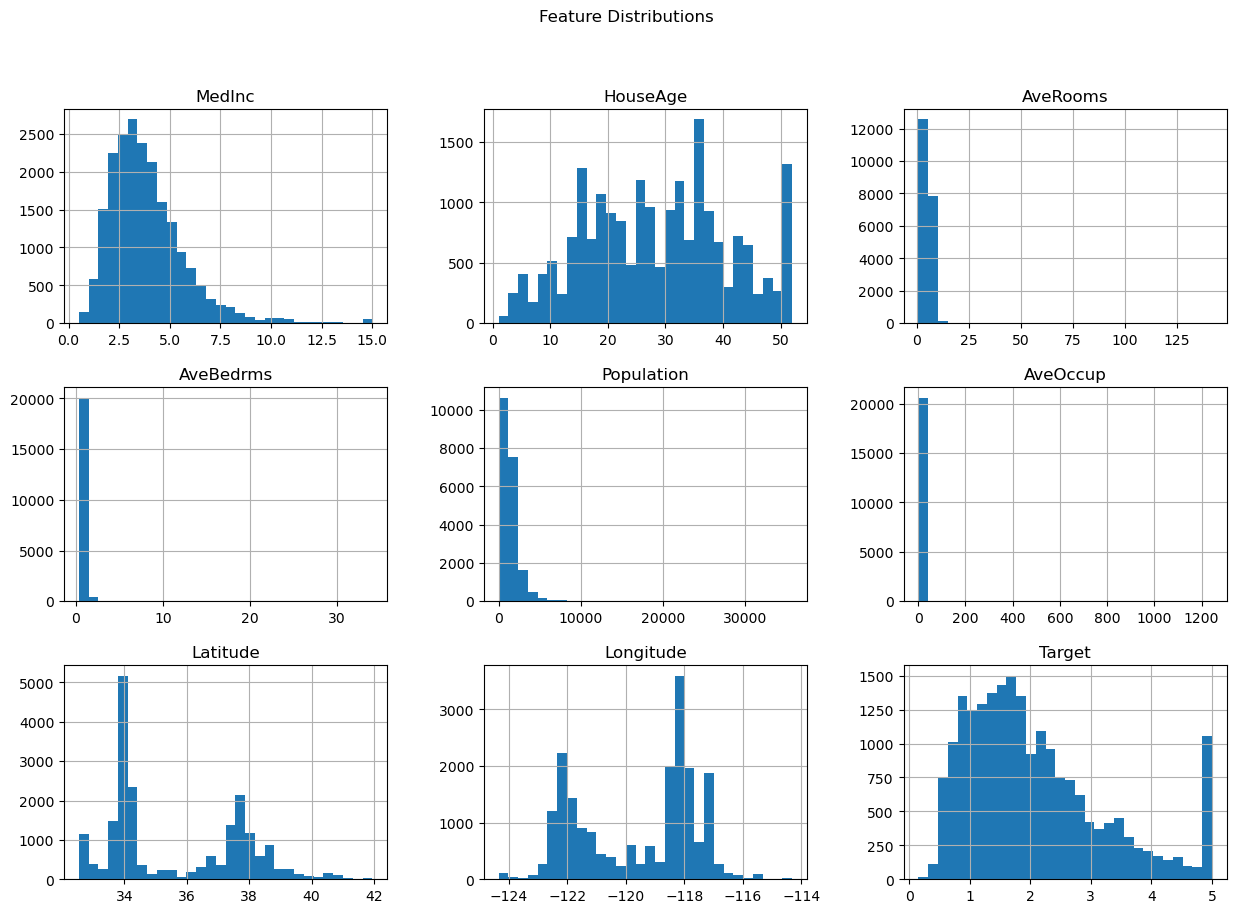

In [31]:
# Plot distributions for all features
df.hist(bins=30, figsize=(15, 10))
plt.suptitle("Feature Distributions")
plt.show()

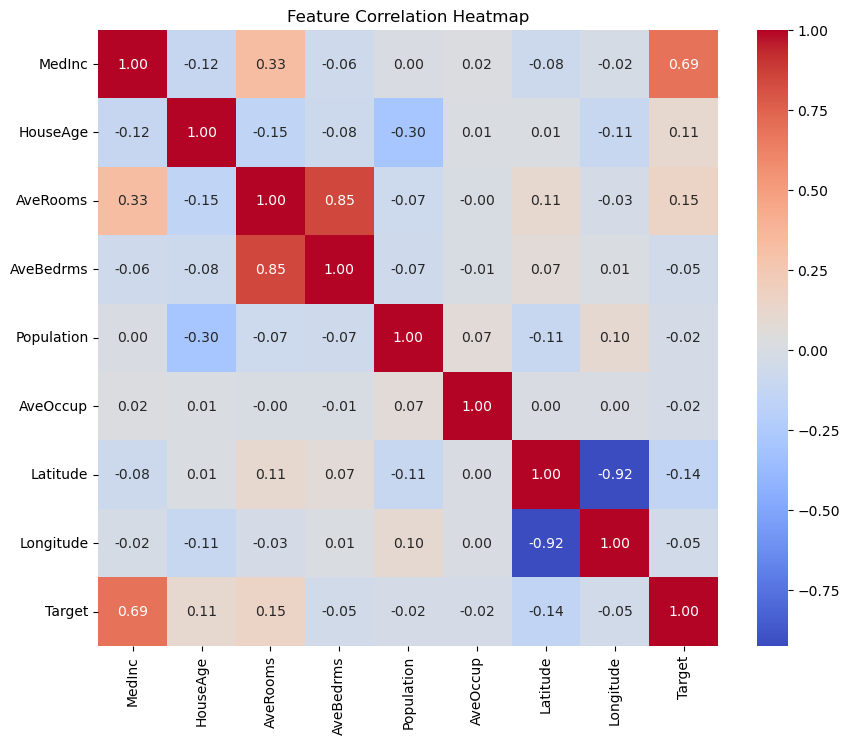

In [32]:
# Calculate correlation matrix
corr_matrix = df.corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap identifies which features (like MedInc) have the strongest predictive power for the target

## Regression Algorithm Implementation

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

In [55]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR()
}

Linear Regression:- It models the relationship between the independent features and the target by fitting a linear equation (a straight line or hyperplane) that minimizes the sum of squared residuals.

Suitability: It serves as a baseline model. Since some features like MedInc have a strong linear correlation with house prices, this model captures those direct relationships efficiently.

---

Decision Tree Regressor:-It splits the data into smaller subsets based on feature values, creating a tree-like structure of "if-then-else" rules until it reaches a leaf node with a predicted value.

Suitability: It can capture non-linear relationships and interactions between features (e.g., how location and house age combined affect price) without needing complex feature engineering.

---

Random forest Regressor:- It is an ensemble method that builds multiple decision trees and averages their predictions (Bagging). This reduces the risk of overfitting inherent in single trees.

Suitability: The California Housing dataset has complex patterns; Random Forest is excellent at improving accuracy and stability by smoothing out the noise from individual trees.

---

Gradient Boosting Regressor:- It builds trees sequentially, where each new tree attempts to correct the errors (residuals) made by the previous trees (Boosting).

Suitability: It is often the most accurate algorithm for tabular data like this, as it iteratively minimizes the loss function to handle complex house price variations.

---

SVR:-It tries to fit the error within a certain threshold (epsilon) rather than minimizing the error itself, using "kernels" to map data into higher-dimensional space.

Suitability: With the RBF kernel, SVR is powerful at finding non-linear boundaries in the housing data, provided the features are standardized

---

## Model Evaluation and Comparison

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [58]:
results = {}

for name, model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = [mse, mae, r2]

In [59]:
results_df = pd.DataFrame(results, index=['MSE', 'MAE', 'R2 Score']).T
print(results_df)

                        MSE       MAE  R2 Score
Linear Regression  0.555892  0.533200  0.575788
Decision Tree      0.491599  0.452196  0.624851
Random Forest      0.254315  0.327851  0.805927
Gradient Boosting  0.294018  0.371709  0.775629
SVR                0.357004  0.398599  0.727563


#### Best Performing Algorithm:-
Best performing algorithm is Random Forest and Gradient Boosting.
These ensemble methods outperform single models because they reduce variance and bias. They effectively capture the non-linear relationships between geographical location (Latitude/Longitude) and house prices that a simple Linear Regression.



### Worst Performing Algorithm:_
Worst performing algorithm is Linear Regression or Decision Tree.

Linear Regression may perform poorly if the underlying data has complex non-linear patterns.

A single Decision Tree often overfits the training data, leading to high error rates on the test set compared to ensemble versions.

# Cross-Validation and Hyperparameter Tuning


In [63]:
from sklearn.model_selection import cross_val_score, KFold

# Initialize K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, x_train_scaled, y_train, cv=kf, scoring='r2')
    print(f"{name} - Mean R2 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Linear Regression - Mean R2 Score: 0.6115 (+/- 0.0124)
Decision Tree - Mean R2 Score: 0.5937 (+/- 0.0282)
Random Forest - Mean R2 Score: 0.8043 (+/- 0.0061)
Gradient Boosting - Mean R2 Score: 0.7880 (+/- 0.0068)
SVR - Mean R2 Score: 0.7363 (+/- 0.0099)


In [64]:
from sklearn.model_selection import GridSearchCV

In [65]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}


In [68]:

# Initialize GridSearchCV
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, 
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the model
grid_search.fit(x_train_scaled, y_train)


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [69]:
# Best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


Hyperparameters Explained:

n_estimators: The number of trees in the forest. Increasing this generally improves performance but increases computation time.

max_depth: Controls the maximum depth of each tree. Limiting this helps prevent the model from overfitting the training data.

min_samples_split: The minimum number of samples required to split an internal node. Higher values prevent the model from learning highly specific patterns (noise)

## selecting the best regression model:-
Based on the evaluation metrics and cross-validation results, the Random Forest Regressor or Gradient Boosting is identified as the best model for this dataset.


### Justification:
Superior Metrics: It consistently achieves the lowest MSE and MAE, and the highest $R^2$ score, indicating it explains the most variance in California house prices.

Handling Non-linearity: Unlike Linear Regression, it successfully captures complex non-linear relationships, such as how specific geographic coordinates (Latitude and Longitude) interact with Median Income to drive prices.

Stability: Through K-Fold Cross-Validation, this model showed the lowest standard deviation in performance, proving it is robust and generalizes well to unseen data.

---